In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score)

import matplotlib.pyplot as plt


: 

In [ ]:
df = pd.read_csv("../data/processed/clauses_clean.csv")

In [ ]:

df

,point_id,quote_text,case_id,classification,label,topic_id,topic_title,service_id,document_id
0,6132,Both you and Stack Overflow hereby irrevocably...,242,bad,Risky,44,Jurisdiction and governing laws,312,352.0
1,9860,Sie haben jederzeit das Recht unentgeltlich Au...,195,good,Safe,34,User Choice,1700,1625.0
2,9859,"Ein Teil der Daten wird erhoben, um eine fehle...",196,good,Safe,41,Personal Data,1700,1625.0
3,4957,Please note that we are not responsible for ot...,278,neutral,Neutral,32,Guarantee,820,725.0
4,4960,"Your name, email address and optional informat...",228,good,Safe,36,Transparency,820,725.0
...,...,...,...,...,...,...,...,...,...
22492,8825,In order to use the services provided on the S...,152,neutral,Neutral,31,Governance,2074,2262.0
22493,12892,<p>We use the Device Information that we colle...,190,neutral,Neutral,41,Personal Data,319,227.0
22494,4959,"Privacy, Security, Cookies and Warranty",199,good,Safe,36,Transparency,820,725.0
22495,5031,We zullen je persoonsgegevens nooit aan derden...,305,good,Safe,28,Law and Government Requests,844,757.0


In [ ]:
data = df[["quote_text", "label"]].copy()
data.head()

,quote_text,label
0,Both you and Stack Overflow hereby irrevocably...,Risky
1,Sie haben jederzeit das Recht unentgeltlich Au...,Safe
2,"Ein Teil der Daten wird erhoben, um eine fehle...",Safe
3,Please note that we are not responsible for ot...,Neutral
4,"Your name, email address and optional informat...",Safe


In [ ]:
X = data["quote_text"]
y = data["label"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state= 42, stratify=y)

In [ ]:
X_train

14781    You agree to keep your username and password s...
14912    Neither TopLogger.nu nor its suppliers and lic...
15517    This Privacy Policy is based on the General Da...
19760    Should any provision of these General Terms an...
10589    It is SpanishDict’s policy to terminate member...
                               ...                        
10714    You agree that regardless of any statute or la...
5747     You may cancel your Account at any time from w...
656                 Updated November 23, 2020.</em>\r\n</p
7050     You may also have a right to request restricti...
19869    <p>You agree to indemnify and hold New Vector ...
Name: quote_text, Length: 16872, dtype: str

In [ ]:
X_test

4345     In case of the violation of third parties’ leg...
10677                                              obscene
3827     Third-party cookies may be placed on your devi...
8403     \r\n<p>We may use the data we collect to perso...
17866                                        July 24, 2021
                               ...                        
13142    5.4.5.\r\nYou have the right to be “forgotten”...
21314    Forgetting your Data <p> You can request that ...
7960     Failure to do so shall constitute a breach of ...
10587    Procedure for Making Claims of Copyright Infri...
6903     We collect Personal Information from you when ...
Name: quote_text, Length: 5625, dtype: str

In [ ]:
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True, strip_accents="unicode")

In [ ]:
nb = MultinomialNB(alpha=1.0)

In [ ]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
nb.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [ ]:
y_pred = nb.predict(X_test_tfidf)
print(y_pred[:10])

['Neutral' 'Neutral' 'Risky' 'Risky' 'Neutral' 'Neutral' 'Neutral'
 'Neutral' 'Risky' 'Neutral']


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("accuracy :", accuracy,"%")

accuracy : 0.8028444444444445 %


In [ ]:
F1score = f1_score(y_test, y_pred, average= "weighted")
print(F1score)

0.8006952001254152


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Neutral       0.81      0.88      0.84      2440
       Risky       0.76      0.82      0.79      1754
        Safe       0.87      0.66      0.75      1431

    accuracy                           0.80      5625
   macro avg       0.81      0.78      0.79      5625
weighted avg       0.81      0.80      0.80      5625



In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Safe", "Risky", "Neutral"]
)

print(cm)

[[ 942  218  271]
 [  76 1437  241]
 [  64  239 2137]]


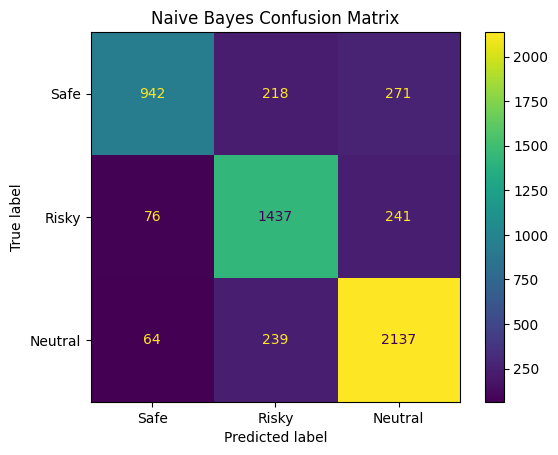

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Safe", "Risky", "Neutral"],
    cmap="blues"
)

disp.plot()
plt.title("Naive Bayes Confusion Matrix")
plt.show()

In [ ]:
new_text = [
    "We do not sell your personal information to third parties.",
    "We may share your personal information with third-party companies.",
    "This privacy policy was last updated in 2024.",
    "You can delete your account and request deletion of your personal data.",
    "We reserve the right to suspend your account at any time."]

new_text_tfidf = tfidf.transform(new_text)

predictions = nb.predict(new_text_tfidf)

for text, prediction in zip(new_text, predictions):
    print("Text:", text)
    print("Prediction:", prediction)

Text: We do not sell your personal information to third parties.
Prediction: Safe
Text: We may share your personal information with third-party companies.
Prediction: Risky
Text: This privacy policy was last updated in 2024.
Prediction: Neutral
Text: You can delete your account and request deletion of your personal data.
Prediction: Safe
Text: We reserve the right to suspend your account at any time.
Prediction: Risky
